# ![Machine Learning Lab](banner.jpg)

# Laboratorio 10 - Actividad

## Instrucciones generales

1. Esta actividad debe ser entregada antes de la fecha limite y es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab10.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. **Manejo y preparación de datos biológicos**: Desarrollar habilidades para explorar, limpiar y estructurar secuencias de ADN para modelos de deep learning.

2. **Implementación de modelos secuenciales**: Aplicar redes neuronales recurrentes (LSTM y GRU) para predecir el siguiente nucleótido en una secuencia de ADN, comprendiendo sus arquitecturas y diferencias.

3. **Evaluación y análisis de modelos predictivos**: Evaluar el desempeño de modelos en tareas de predicción de secuencias y analizar cómo varía la precisión en función de la longitud del contexto.

---

## Contexto

En esta actividad trabajaremos con el dataset **DNA Sequence Prediction**, que contiene secuencias de nucleótidos de genes humanos obtenidas de la base de datos NCBI Gene Database. Cada secuencia está compuesta por los 4 nucleótidos del ADN: **Adenina (A)**, **Timina (T)**, **Citosina (C)** y **Guanina (G)**.

La tarea consiste en predecir el **siguiente nucleótido** dada una ventana de contexto de nucleótidos previos.

Dataset: [DNA Sequence Prediction](https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction)



---

## Instrucciones

### 1. Descarga de datos y preprocesamiento (5%)

1. Descargue el dataset, explore su estructura: identifique las columnas disponibles, tipos de genes y distribución de longitudes de secuencias.
2. Limpie las secuencias: remueva los delimitadores `<>`, convierta a mayúsculas y filtre solo caracteres válidos (A, T, C, G).
3. Considere que el dataset contiene secuencias de hasta 1000 nucleótidos. Para esta actividad se recomienda trabajar con secuencias de **longitud moderada** (por ejemplo, ≤ 200 nucleótidos). Si lo considera necesario, puede trabajar con un subconjunto del conjunto de datos original que determine adecuado dependiendo de las capacidades de su Hardware.
5. Cree **ventanas deslizantes** de tamaño $k = 20$: para cada posición en una secuencia, la entrada es la subsecuencia de longitud $k$ y el target es el nucleótido siguiente.
6. Puede utilizar las particiones proporcionadas por el dataset (train/validation/test), o crearlas a partir de train.

---

### 2. Modelos a implementar (30%)

Desarrolle dos modelos de deep learning para predecir el siguiente nucleótido:

1. **Modelo LSTM**: Implemente una red que haga uso de al menos **dos capas LSTM**.
2. **Modelo GRU**: Implemente una red que haga uso de al menos **dos capas GRU**.

---

### 3. Entrenamiento y Evaluación (35%)

1. Entrene cada uno de los modelos por el numero de épocas que considere necesario. Explique Por qué.
2. Muestre las **gráficas de pérdida (loss) y precisión (accuracy) por época** para entrenamiento y validación de ambos modelos.
4. ¿Cuál modelo obtuvo mejor desempeño? y ¿Como se compara con la baseline aleatoria?.

---

### 4. Análisis de la longitud de contexto (30%)

1. Tome la mejor arquitectura del punto anterior y vuelva a entrenar utilizando ventanas de contexto de **50 y 80** nucleótidos.
2. Para cada longitud de contexto:
   - Muestre las curvas de pérdida.
   - Reporte la precisión obtenida en el conjunto de test.
3. Anote y explique las diferencias en el rendimiento según la longitud de contexto. ¿Cómo afecta tener más contexto a la capacidad predictiva del modelo?

---


# **1. Descarga de datos y preprocesamiento**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

Se definen las rutas para la lectura y carga de los distintos archivos que conforman la totalidad del conjunto de datos. Se aprovecha que el conjunto de datos ya se encuentra dividido en datos de entrenamiento, validación y prueba

In [2]:
validation_path = "../datasets/validation.csv"
train_path = "../datasets/train.csv"
test_path = "../datasets/test.csv"

Se cargan los archivos correspondientes haciendo uso de **DataFrames** para facilitar su manipulación y análisis

In [3]:
validation_df = pd.read_csv(validation_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

Se define la función **explore_file** la cual se encarga de realizar un análisis exploratorio básico sobre los **DataFrames** cargados. Específicamente para cada uno de los tres **DataFrames** informa acerca de las columnas que lo componen, la cantidad de valores faltantes por columna, la distribución de los valores de la columna **Gene Type** y la distribución y estadísticas de la longitud de las secuencias presentes en el archivo

In [4]:
def explore_file(df, name):

    print(f"ANALYSIS FOR --{name}-- SET")

    print("\nAVAILABLE COLUMNS:")
    print(df.columns.tolist())

    print("\nMISSING VALUES PER COLUMN:")
    print(df.isnull().sum())

    if "GeneType" in df.columns:
        print("\nGENE TYPE DISTRIBUTION:")
        print(df["GeneType"].value_counts())
    else:
        print("\n!!WARNING¡¡: 'GeneType' COLUMN NOT FOUND")
    
    df["sequence_length"] = df["NucleotideSequence"].str.strip("<>").str.len()
    
    print("\nSEQUENCE LENGTH STATISTICS:")
    print(df["sequence_length"].describe())

    plt.figure(figsize = (10, 5))
    sns.histplot(df["sequence_length"], kde = True, bins = 50, color = "darkblue")
    plt.title(f"SEQUENCE LENGTH DISTRIBUTION --{name}--")
    plt.xlabel("NUCLEOTIDS (LENGTH)")
    plt.ylabel("FREQUENCY")
    plt.grid(axis = "y", alpha = 0.3)
    plt.show()


In [5]:
file_mapping = {
    "TRAINING" : train_df,
    "VALIDATION" : validation_df,
    "TEST" : test_df
}

ANALYSIS FOR --TRAINING-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               10220
BIOLOGICAL_REGION     6925
ncRNA                 2497
snoRNA                1148
PROTEIN_CODING         524
tRNA                   488
OTHER                  366
rRNA                   277
snRNA                  145
scRNA                    3
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    22593.000000
mean       359.724871
std        260.474730
min          2.000000
25%        120.000000
50%        295.000000
75%        518.000000
max       1000.000000
Name: sequence_length, dtype: float64


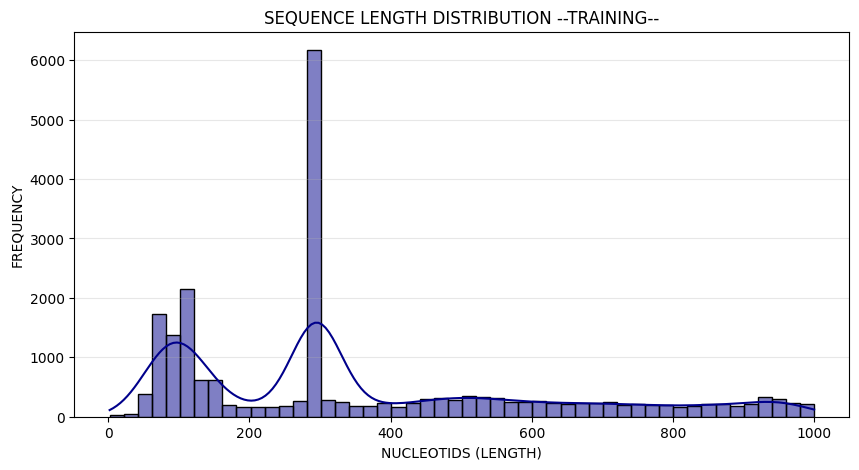

ANALYSIS FOR --VALIDATION-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               2133
BIOLOGICAL_REGION    1398
ncRNA                 516
snoRNA                239
PROTEIN_CODING        101
OTHER                  88
tRNA                   72
snRNA                  22
rRNA                    8
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    4577.000000
mean      362.734979
std       259.815403
min         7.000000
25%       126.000000
50%       295.000000
75%       522.000000
max       998.000000
Name: sequence_length, dtype: float64


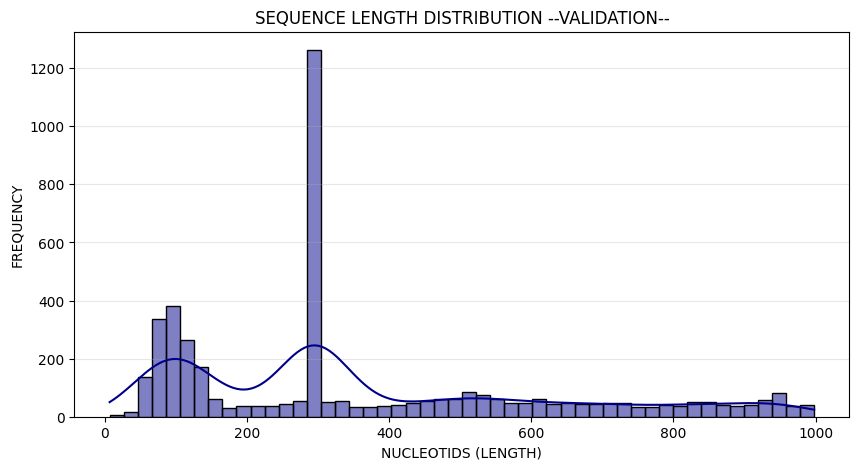

ANALYSIS FOR --TEST-- SET

AVAILABLE COLUMNS:
['Unnamed: 0', 'NCBIGeneID', 'Symbol', 'Description', 'GeneType', 'GeneGroupMethod', 'NucleotideSequence']

MISSING VALUES PER COLUMN:
Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64

GENE TYPE DISTRIBUTION:
GeneType
PSEUDO               3800
BIOLOGICAL_REGION    2651
ncRNA                 894
snoRNA                405
PROTEIN_CODING        184
tRNA                  148
OTHER                 133
rRNA                   72
snRNA                  38
scRNA                   1
Name: count, dtype: int64

SEQUENCE LENGTH STATISTICS:
count    8326.000000
mean      365.491833
std       261.984806
min         4.000000
25%       128.000000
50%       295.000000
75%       524.000000
max      1000.000000
Name: sequence_length, dtype: float64


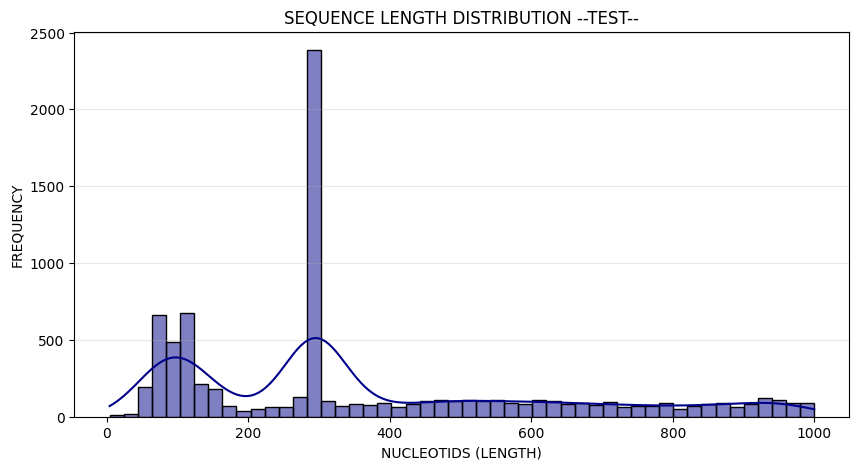

In [6]:
for label, dataframe in file_mapping.items():
    explore_file(dataframe, label)

Como se puede observa, todos los archviso cuentan con las mismas columnas, además de una columna identificador que puede ser eliminada sin perdida de información. De igual forma, ninguno de los **DataFrames** presenta valores faltantes y la distribución de las longitudes de las secuencias se centra aproximadamente en las 300 bases, con un máximo de 1000 bases en cada uno de los archivos

Se define la función **clean_genomic_sequences** para, en cada **DataFrame** eliminar la columna asociada al identificador, eliminar los indicadores de inicio y fin de secuencia y, finalmente, añadir una columna llamada **Clean Sequence** en la cual se encuentra la versión final de la secuencia, la cual corresponde a la misma sin caracteres especiales y con todas las bases en mayuscula

In [7]:
def clean_genomic_sequences(df):

    df.drop(columns = ["Unnamed: 0"])
    
    temp_seqs = df["NucleotideSequence"].str.strip("<>").str.upper()
    df["CleanSequence"] = temp_seqs.str.replace(r"[^ATCG]", "", regex = True)

In [8]:
for label, dataframe in file_mapping.items():
    print(f"CLEANING --{label}--")
    clean_genomic_sequences(dataframe)

CLEANING --TRAINING--
CLEANING --VALIDATION--
CLEANING --TEST--


In [9]:
print("TRAINING SET VERIFICATION")
print(train_df.head())

TRAINING SET VERIFICATION
   Unnamed: 0  NCBIGeneID        Symbol  \
0           0   106481178      RNU4-21P   
1           1   123477792  LOC123477792   
2           2   113174975  LOC113174975   
3           3   116216107  LOC116216107   
4           4       28502      IGHD2-21   

                                         Description           GeneType  \
0               RNA, U4 small nuclear 21, pseudogene             PSEUDO   
1                Sharpr-MPRA regulatory region 12926  BIOLOGICAL_REGION   
2                 Sharpr-MPRA regulatory region 7591  BIOLOGICAL_REGION   
3  CRISPRi-validated cis-regulatory element chr10...  BIOLOGICAL_REGION   
4                immunoglobulin heavy diversity 2-21              OTHER   

  GeneGroupMethod                                 NucleotideSequence  \
0   NCBI Ortholog  <AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...   
1   NCBI Ortholog  <CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...   
2   NCBI Ortholog  <TTCCCAATTTTTCCTCTGCTTTTTAATT

De igual forma, se define la función **create_sliding_windows** la cual se aplica a cada uno de los tres **DataFrames** y se encarga de generar los pares de secuencia y objetivos para la construcción de los modelos. Esta función extrae secuencias de longitud **k**, la cual es dada como parámetro, y asocia el siguiente nucleotido como valores a predecir. Cabe resaltar que se decide trabajar con todas las secuencias del conjunto de datos (sin restricción de tamaño) ya que, luego de experimentar, no se cuenta con restricciones de hardware que sean considerables

In [10]:
def create_sliding_windows(df, k = 20):

    valid_df = df[df["CleanSequence"].str.len() > k].copy()
    print(f"TOTAL SEQUENCES FOR WINDOWING: {len(valid_df)}")

    X = []
    y = []

    for seq in valid_df["CleanSequence"]:

        for i in range(len(seq) - k):
            window = seq[i : i + k]
            target = seq[i + k]
            
            X.append(window)
            y.append(target)
    
    return X, y

In [11]:
windowed_data = {}

In [12]:
for label, dataframe in file_mapping.items():
    print(f"WINDOWING --{label}--")
    X, y = create_sliding_windows(dataframe)
    windowed_data[label] = (X, y)

WINDOWING --TRAINING--


TOTAL SEQUENCES FOR WINDOWING: 22568
WINDOWING --VALIDATION--
TOTAL SEQUENCES FOR WINDOWING: 4571
WINDOWING --TEST--
TOTAL SEQUENCES FOR WINDOWING: 8319


Se crean las ventanas para cada uno de los subconjunto de datos usando como tamaño de ventana **k = 20**. Este valor se decide para llevar a cabo el entrenamiento de los modelos base

In [13]:
X_train, y_train = windowed_data["TRAINING"]
X_val, y_val     = windowed_data["VALIDATION"]
X_test, y_test   = windowed_data["TEST"]

Se lleva a cabo una verificación sobre el conjunto de entrenamiento para validar que los pares se están creando correctamente

In [14]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 30 BP): {first_seq[:30]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train[i]} --> Next Nucleotide (y_{i}): {y_train[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 30 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAG

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): AGCTTAGCACAGTGGCAGTA --> Next Nucleotide (y_0): T
Window 1 (X_1): GCTTAGCACAGTGGCAGTAT --> Next Nucleotide (y_1): C
Window 2 (X_2): CTTAGCACAGTGGCAGTATC --> Next Nucleotide (y_2): A


Dado que la entrada de los modelos de ML debe ser numérica, se codifican los conjuntos de ventanas y nucleotido objetivo creados anteriormente utilizando una codificación sencilla en el rango entero de 0 a 3. Esta codificación se aplica a todos los subconjuntos de datos para garantizar que están preparados para el proceso de entrenamiento de los modelos base

In [15]:
char_to_int = {"A": 0, "C": 1, "G": 2, "T": 3}

In [16]:
def encode_sequences(X_list, y_list):
    
    X_encoded = np.array([[char_to_int[char] for char in seq] for seq in X_list], dtype = np.uint8)
    y_encoded = np.array([char_to_int[char] for char in y_list], dtype = np.uint8)
    
    return X_encoded, y_encoded

In [17]:
X_train_enc, y_train_enc = encode_sequences(X_train, y_train)
X_val_enc, y_val_enc     = encode_sequences(X_val, y_val)
X_test_enc, y_test_enc   = encode_sequences(X_test, y_test)

Se lleva a cabo una verificación sobre el conjunto de entrenamiento para validar que los pares codificados se están creando correctamente

In [18]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 30 BP): {first_seq[:30]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train_enc[i]} --> Next Nucleotide (y_{i}): {y_train_enc[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 30 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAG

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): [0 2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0] --> Next Nucleotide (y_0): 3
Window 1 (X_1): [2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3] --> Next Nucleotide (y_1): 1
Window 2 (X_2): [1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1] --> Next Nucleotide (y_2): 0


# **2. Modelos a implementar**

In [19]:
from tensorflow.keras import layers, models
import tensorflow as tf

I0000 00:00:1777051237.691580   28150 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777051237.711695   28150 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777051238.219461   28150 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [20]:
EMBEDDING_DIM = 32
INPUT_LENGTH = 20
VOCAB_SIZE = 4

In [21]:
lstm_model = models.Sequential([

    layers.Input(shape = (INPUT_LENGTH,)),
    
    layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMBEDDING_DIM),
    
    layers.LSTM(128, return_sequences = True),
    layers.Dropout(0.2),
    
    layers.LSTM(128),
    layers.Dropout(0.2),
    
    layers.Dense(VOCAB_SIZE, activation = "softmax")
])

W0000 00:00:1777051238.387243   28150 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1777051238.391921   28150 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777051238.472573   28150 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9088 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [22]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,660 (838.52 KB)

 Trainable params: 214,660 (838.52 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
lstm_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [24]:
gru_model = models.Sequential([
    
    layers.Input(shape = (INPUT_LENGTH,)),
    
    layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMBEDDING_DIM),
    
    layers.GRU(128, return_sequences = True),
    layers.Dropout(0.2),
    
    layers.GRU(128),
    layers.Dropout(0.2),

    layers.Dense(VOCAB_SIZE, activation = "softmax")
])

In [25]:
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20, 128)        │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,924 (632.52 KB)

 Trainable params: 161,924 (632.52 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
gru_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

# **3. Entrenamiento y validación**

In [27]:
BATCH_SIZE = 1024 

In [28]:
def make_genomic_dataset(X, y, shuffle = False):
    
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size = 10000)
    
    dataset = dataset.batch(BATCH_SIZE).prefetch(buffer_size = tf.data.AUTOTUNE)
    
    return dataset

In [29]:
train_ds = make_genomic_dataset(X_train_enc, y_train_enc, shuffle = True)
val_ds = make_genomic_dataset(X_val_enc, y_val_enc, shuffle = False)
test_ds  = make_genomic_dataset(X_test_enc, y_test_enc, shuffle = False)

In [30]:
history_lstm = lstm_model.fit(
    train_ds,           
    validation_data = val_ds,
    epochs = 100,        
    verbose = 1
)

Epoch 1/100


I0000 00:00:1777051240.096093   28251 cuda_dnn.cc:461] Loaded cuDNN version 91900


7496/7496 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.3428 - loss: 1.3287 - val_accuracy: 0.3490 - val_loss: 1.3236
Epoch 2/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3635 - loss: 1.3018 - val_accuracy: 0.3723 - val_loss: 1.2919
Epoch 3/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3763 - loss: 1.2841 - val_accuracy: 0.3810 - val_loss: 1.2803
Epoch 4/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3827 - loss: 1.2753 - val_accuracy: 0.3867 - val_loss: 1.2718
Epoch 5/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3870 - loss: 1.2686 - val_accuracy: 0.3911 - val_loss: 1.2653
Epoch 6/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3902 - loss: 1.2637 - val_accuracy: 0.3941 - val_loss: 1.2604
Epoch 7/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3925 - loss: 1.2598 - val_accuracy: 0.3970 - val_loss: 1.2567
Epoch 8/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.3945 - loss: 1.256

In [31]:
acc_lstm = history_lstm.history["accuracy"]
val_acc_lstm = history_lstm.history["val_accuracy"]
loss_lstm = history_lstm.history["loss"]
val_loss_lstm = history_lstm.history["val_loss"]

epochs_range = range(len(acc_lstm))

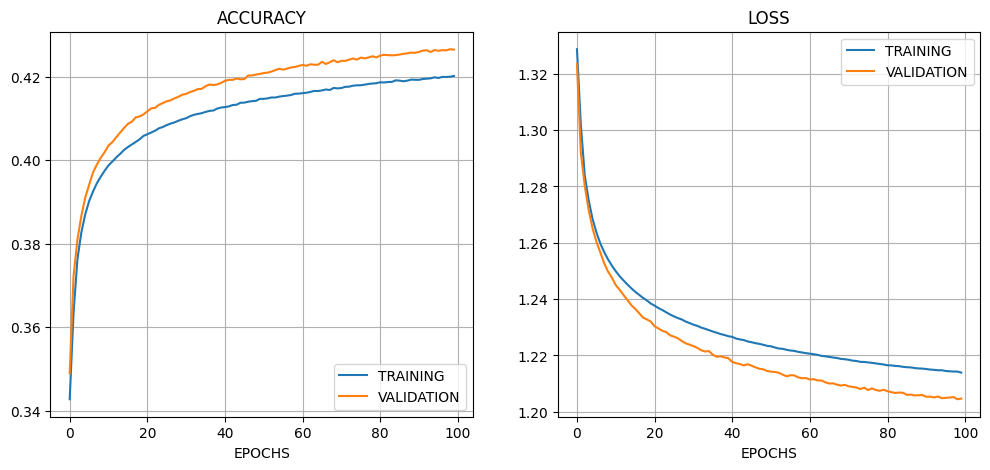

In [32]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_lstm, label = "TRAINING")
plt.plot(epochs_range, val_acc_lstm, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_lstm, label = "TRAINING")
plt.plot(epochs_range, val_loss_lstm, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

In [33]:
results_lstm = lstm_model.evaluate(test_ds)

2810/2810 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4270 - loss: 1.2010


In [34]:
print(f"LOSS IN TEST: {results_lstm[0]:.4f}")
print(f"ACCURACY IN TEST: {results_lstm[1]:.4f}")

LOSS IN TEST: 1.2010
ACCURACY IN TEST: 0.4270


In [40]:
lstm_model.save("../models/lstm_model.keras")

In [35]:
history_gru = gru_model.fit(
    train_ds,           
    validation_data = val_ds,
    epochs = 100,        
    verbose = 1
)

Epoch 1/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3435 - loss: 1.3292 - val_accuracy: 0.3480 - val_loss: 1.3259
Epoch 2/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.3598 - loss: 1.3093 - val_accuracy: 0.3669 - val_loss: 1.3002
Epoch 3/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3707 - loss: 1.2929 - val_accuracy: 0.3744 - val_loss: 1.2892
Epoch 4/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3762 - loss: 1.2849 - val_accuracy: 0.3793 - val_loss: 1.2819
Epoch 5/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3799 - loss: 1.2794 - val_accuracy: 0.3840 - val_loss: 1.2763
Epoch 6/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3829 - loss: 1.2751 - val_accuracy: 0.3861 - val_loss: 1.2732
Epoch 7/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3854 - loss: 1.2715 - val_accuracy: 0.3891 - val_loss: 1.2683
Epoch 8/100
7496/7496 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.3872 -

In [36]:
acc_gru = history_gru.history["accuracy"]
val_acc_gru = history_gru.history["val_accuracy"]
loss_gru = history_gru.history["loss"]
val_loss_gru = history_gru.history["val_loss"]

epochs_range = range(len(acc_gru))

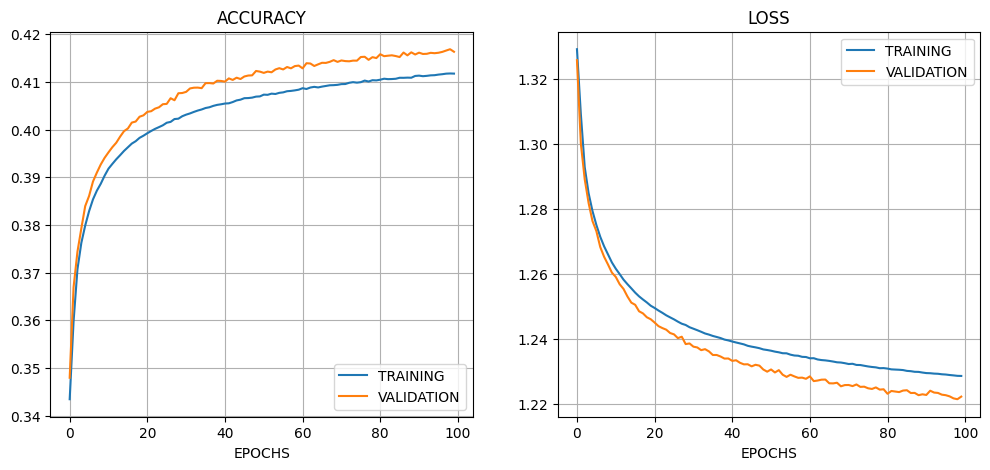

In [37]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_gru, label = "TRAINING")
plt.plot(epochs_range, val_acc_gru, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_gru, label = "TRAINING")
plt.plot(epochs_range, val_loss_gru, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

In [38]:
results_gru = gru_model.evaluate(test_ds)

2810/2810 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4178 - loss: 1.2174


In [39]:
print(f"LOSS IN TEST: {results_gru[0]:.4f}")
print(f"ACCURACY IN TEST: {results_gru[1]:.4f}")

LOSS IN TEST: 1.2174
ACCURACY IN TEST: 0.4178


In [41]:
gru_model.save("../models/gru_model.keras")

# **4. Análisis de la longitud del contexto**

In [42]:
windowed_data_50 = {}

In [43]:
for label, dataframe in file_mapping.items():
    print(f"WINDOWING --{label}--")
    X, y = create_sliding_windows(dataframe, k = 50)
    windowed_data_50[label] = (X, y)

WINDOWING --TRAINING--
TOTAL SEQUENCES FOR WINDOWING: 22480
WINDOWING --VALIDATION--
TOTAL SEQUENCES FOR WINDOWING: 4554
WINDOWING --TEST--
TOTAL SEQUENCES FOR WINDOWING: 8286


In [44]:
X_train_50, y_train_50 = windowed_data_50["TRAINING"]
X_val_50, y_val_50     = windowed_data_50["VALIDATION"]
X_test_50, y_test_50   = windowed_data_50["TEST"]

In [45]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 60 BP): {first_seq[:60]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train_50[i]} --> Next Nucleotide (y_{i}): {y_train_50[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 60 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCA

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTG --> Next Nucleotide (y_0): A
Window 1 (X_1): GCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGA --> Next Nucleotide (y_1): T
Window 2 (X_2): CTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGAT --> Next Nucleotide (y_2): T


In [46]:
X_train_enc_50, y_train_enc_50 = encode_sequences(X_train_50, y_train_50)
X_val_enc_50, y_val_enc_50     = encode_sequences(X_val_50, y_val_50)
X_test_enc_50, y_test_enc_50   = encode_sequences(X_test_50, y_test_50)

In [47]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 60 BP): {first_seq[:60]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train_enc_50[i]} --> Next Nucleotide (y_{i}): {y_train_enc_50[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 60 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCA

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): [0 2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3
 3 0 3 1 1 2 0 2 2 1 2 3 2] --> Next Nucleotide (y_0): 0
Window 1 (X_1): [2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3 3
 0 3 1 1 2 0 2 2 1 2 3 2 0] --> Next Nucleotide (y_1): 3
Window 2 (X_2): [1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3 3 0
 3 1 1 2 0 2 2 1 2 3 2 0 3] --> Next Nucleotide (y_2): 3


In [48]:
windowed_data_80 = {}

In [49]:
for label, dataframe in file_mapping.items():
    print(f"WINDOWING --{label}--")
    X, y = create_sliding_windows(dataframe, k = 80)
    windowed_data_80[label] = (X, y)

WINDOWING --TRAINING--
TOTAL SEQUENCES FOR WINDOWING: 20474
WINDOWING --VALIDATION--
TOTAL SEQUENCES FOR WINDOWING: 4172
WINDOWING --TEST--
TOTAL SEQUENCES FOR WINDOWING: 7554


In [50]:
X_train_80, y_train_80 = windowed_data_80["TRAINING"]
X_val_80, y_val_80     = windowed_data_80["VALIDATION"]
X_test_80, y_test_80   = windowed_data_80["TEST"]

In [51]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 90 BP): {first_seq[:90]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train_80[i]} --> Next Nucleotide (y_{i}): {y_train_80[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 90 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCAATTGAAAACTTTTCTCGATACCCTTCTGTG

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCAATTGAAAACTTTTCTCGATA --> Next Nucleotide (y_0): C
Window 1 (X_1): GCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCAATTGAAAACTTTTCTCGATAC --> Next Nucleotide (y_1): C
Window 2 (X_2): CTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCAATTGAAAACTTTTCTCGATACC --> Next Nucleotide (y_2): C


In [52]:
X_train_enc_80, y_train_enc_80 = encode_sequences(X_train_80, y_train_80)
X_val_enc_80, y_val_enc_80     = encode_sequences(X_val_80, y_val_80)
X_test_enc_80, y_test_enc_80   = encode_sequences(X_test_80, y_test_80)

In [53]:
print("TRAINING SET VERIFICATION")

first_seq = file_mapping["TRAINING"]["CleanSequence"].iloc[0]
print(f"ORIGINAL SEQUENCE (FIRST 90 BP): {first_seq[:90]}")

print("\nFIRST 3 WINDOWS AND THEIR TARGETS:")
for i in range(3):
    print(f"Window {i} (X_{i}): {X_train_enc_80[i]} --> Next Nucleotide (y_{i}): {y_train_enc_80[i]}")

TRAINING SET VERIFICATION
ORIGINAL SEQUENCE (FIRST 90 BP): AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGGCGTGATTATTGCCAATTGAAAACTTTTCTCGATACCCTTCTGTG

FIRST 3 WINDOWS AND THEIR TARGETS:
Window 0 (X_0): [0 2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3
 3 0 3 1 1 2 0 2 2 1 2 3 2 0 3 3 0 3 3 2 1 1 0 0 3 3 2 0 0 0 0 1 3 3 3 3 1
 3 1 2 0 3 0] --> Next Nucleotide (y_0): 1
Window 1 (X_1): [2 1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3 3
 0 3 1 1 2 0 2 2 1 2 3 2 0 3 3 0 3 3 2 1 1 0 0 3 3 2 0 0 0 0 1 3 3 3 3 1 3
 1 2 0 3 0 1] --> Next Nucleotide (y_1): 1
Window 2 (X_2): [1 3 3 0 2 1 0 1 0 2 3 2 2 1 0 2 3 0 3 1 0 3 0 2 2 1 0 2 3 2 0 2 2 3 3 3 0
 3 1 1 2 0 2 2 1 2 3 2 0 3 3 0 3 3 2 1 1 0 0 3 3 2 0 0 0 0 1 3 3 3 3 1 3 1
 2 0 3 0 1 1] --> Next Nucleotide (y_2): 1


In [54]:
INPUT_LENGTH = 50

In [55]:
lstm_model_50 = models.Sequential([

    layers.Input(shape = (INPUT_LENGTH,)),
    
    layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMBEDDING_DIM),
    
    layers.LSTM(128, return_sequences = True),
    layers.Dropout(0.2),
    
    layers.LSTM(128),
    layers.Dropout(0.2),
    
    layers.Dense(VOCAB_SIZE, activation = "softmax")
])

In [56]:
lstm_model_50.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,660 (838.52 KB)

 Trainable params: 214,660 (838.52 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
lstm_model_50.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [58]:
train_ds_50 = make_genomic_dataset(X_train_enc_50, y_train_enc_50, shuffle = True)
val_ds_50 = make_genomic_dataset(X_val_enc_50, y_val_enc_50, shuffle = False)
test_ds_50  = make_genomic_dataset(X_test_enc_50, y_test_enc_50, shuffle = False)

In [59]:
history_lstm_50 = lstm_model_50.fit(
    train_ds_50,           
    validation_data = val_ds_50,
    epochs = 100,        
    verbose = 1
)

Epoch 1/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.3463 - loss: 1.3250 - val_accuracy: 0.3543 - val_loss: 1.3177
Epoch 2/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.3674 - loss: 1.2976 - val_accuracy: 0.3801 - val_loss: 1.2817
Epoch 3/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.3846 - loss: 1.2740 - val_accuracy: 0.3909 - val_loss: 1.2666
Epoch 4/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.3920 - loss: 1.2630 - val_accuracy: 0.3968 - val_loss: 1.2572
Epoch 5/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.3970 - loss: 1.2550 - val_accuracy: 0.4022 - val_loss: 1.2493
Epoch 6/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.4009 - loss: 1.2489 - val_accuracy: 0.4058 - val_loss: 1.2427
Epoch 7/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 0.4037 - loss: 1.2442 - val_accuracy: 0.4091 - val_loss: 1.2378
Epoch 8/100
6836/6836 ━━━━━━━━━━━━━━━━━━━━ 71s 10ms/step - accuracy: 

In [60]:
acc_lstm_50 = history_lstm_50.history["accuracy"]
val_acc_lstm_50 = history_lstm_50.history["val_accuracy"]
loss_lstm_50 = history_lstm_50.history["loss"]
val_loss_lstm_50 = history_lstm_50.history["val_loss"]

epochs_range = range(len(acc_lstm_50))

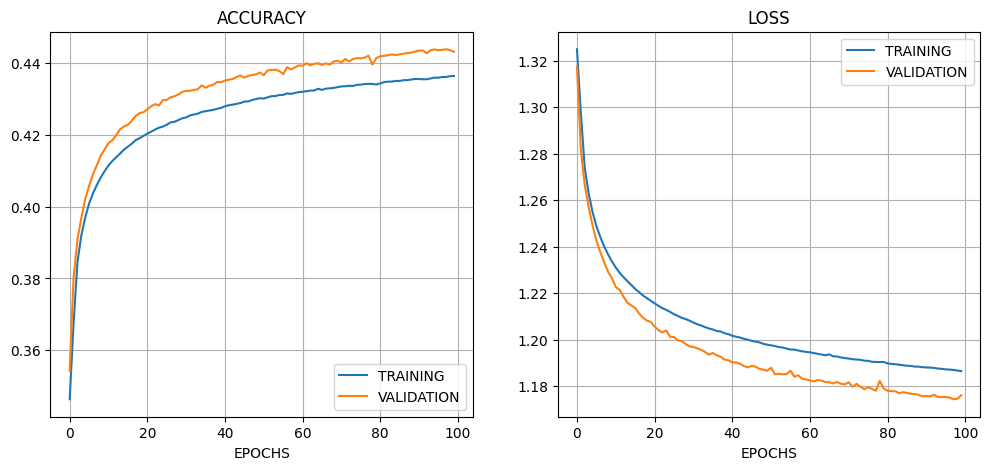

In [61]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_lstm_50, label = "TRAINING")
plt.plot(epochs_range, val_acc_lstm_50, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_lstm_50, label = "TRAINING")
plt.plot(epochs_range, val_loss_lstm_50, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

In [62]:
results_lstm_50 = lstm_model_50.evaluate(test_ds_50)

2566/2566 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4429 - loss: 1.1740


In [63]:
print(f"LOSS IN TEST: {results_lstm_50[0]:.4f}")
print(f"ACCURACY IN TEST: {results_lstm_50[1]:.4f}")

LOSS IN TEST: 1.1740
ACCURACY IN TEST: 0.4429


In [64]:
lstm_model_50.save("../models/lstm_model_50.keras")

In [65]:
INPUT_LENGTH = 80

In [66]:
lstm_model_80 = models.Sequential([

    layers.Input(shape = (INPUT_LENGTH,)),
    
    layers.Embedding(input_dim = VOCAB_SIZE, output_dim = EMBEDDING_DIM),
    
    layers.LSTM(128, return_sequences = True),
    layers.Dropout(0.2),
    
    layers.LSTM(128),
    layers.Dropout(0.2),
    
    layers.Dense(VOCAB_SIZE, activation = "softmax")
])

In [67]:
lstm_model_80.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 80, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 80, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 80, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,660 (838.52 KB)

 Trainable params: 214,660 (838.52 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
lstm_model_80.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [69]:
train_ds_80 = make_genomic_dataset(X_train_enc_80, y_train_enc_80, shuffle = True)
val_ds_80 = make_genomic_dataset(X_val_enc_80, y_val_enc_80, shuffle = False)
test_ds_80  = make_genomic_dataset(X_test_enc_80, y_test_enc_80, shuffle = False)

In [70]:
history_lstm_80 = lstm_model_80.fit(
    train_ds_80,           
    validation_data = val_ds_80,
    epochs = 100,        
    verbose = 1
)

Epoch 1/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 98s 16ms/step - accuracy: 0.3470 - loss: 1.3247 - val_accuracy: 0.3527 - val_loss: 1.3213
Epoch 2/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3607 - loss: 1.3082 - val_accuracy: 0.3719 - val_loss: 1.2929
Epoch 3/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3772 - loss: 1.2856 - val_accuracy: 0.3832 - val_loss: 1.2772
Epoch 4/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3604 - loss: 1.3076 - val_accuracy: 0.3561 - val_loss: 1.3152
Epoch 5/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3660 - loss: 1.2997 - val_accuracy: 0.3837 - val_loss: 1.2765
Epoch 6/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3849 - loss: 1.2744 - val_accuracy: 0.3904 - val_loss: 1.2676
Epoch 7/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 0.3844 - loss: 1.2741 - val_accuracy: 0.3859 - val_loss: 1.2714
Epoch 8/100
6198/6198 ━━━━━━━━━━━━━━━━━━━━ 97s 16ms/step - accuracy: 

In [71]:
acc_lstm_80 = history_lstm_80.history["accuracy"]
val_acc_lstm_80 = history_lstm_80.history["val_accuracy"]
loss_lstm_80 = history_lstm_80.history["loss"]
val_loss_lstm_80 = history_lstm_80.history["val_loss"]

epochs_range = range(len(acc_lstm_80))

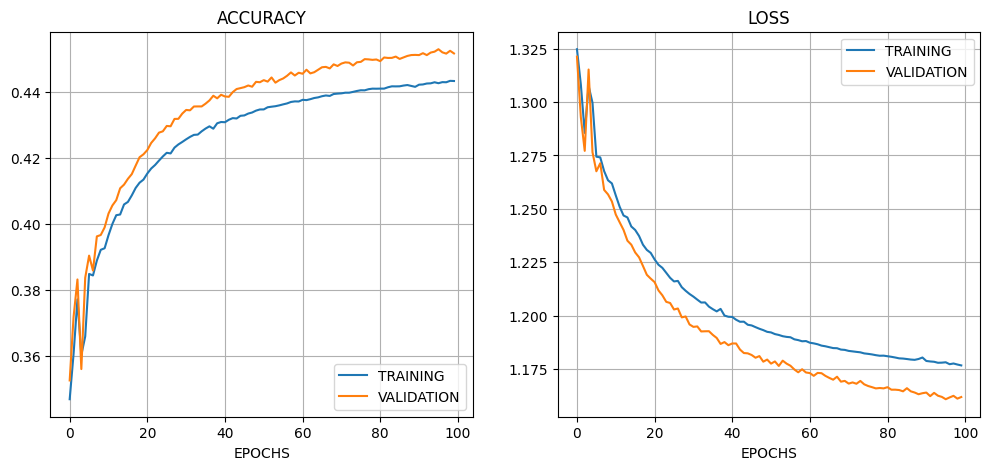

In [72]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_lstm_80, label = "TRAINING")
plt.plot(epochs_range, val_acc_lstm_80, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_lstm_80, label = "TRAINING")
plt.plot(epochs_range, val_loss_lstm_80, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

In [73]:
results_lstm_80 = lstm_model_80.evaluate(test_ds_80)

2331/2331 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4501 - loss: 1.1629


In [74]:
print(f"LOSS IN TEST: {results_lstm_80[0]:.4f}")
print(f"ACCURACY IN TEST: {results_lstm_80[1]:.4f}")

LOSS IN TEST: 1.1629
ACCURACY IN TEST: 0.4501


In [75]:
lstm_model_80.save("../models/lstm_model_80.keras")